C:\Users\Juanan\AppData\Local\Temp\ipykernel_17208\1378498730.py:335: FutureWarning:

The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.

C:\Users\Juanan\AppData\Local\Temp\ipykernel_17208\1378498730.py:335: FutureWarning:

The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.

c:\Users\Juanan\anaconda3\envs\my_quant_lab\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

invalid value encountered in log

C:\Users\Juanan\AppData\Local\Temp\ipykernel_17208\1378498730.py:335: FutureWarning:

The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA v

=== Equity Core + Tactical Sleeve Allocator ===
Mode: Sortino for sleeve target vol, IR for base allocation, pairwise corr penalty among eligible alts
Tactical mode: ALWAYS FULL TACTICAL SLEEVE
Equity graph includes correctly weighted ES and alt contribution lines
Includes rolling 252d beta and annualized alpha vs benchmark
Equity core symbol: ES=F
Alternative symbols: ['NQ=F', 'RTY=F', 'ZN=F', 'BTC=F', 'GC=F', 'SI=F', 'YM=F', 'RY=F', 'ZF=F', 'ZT=F', 'CL=F', 'NG=F', 'ZC=F', 'ZS=F', 'LE=F', 'HE=F', 'CC=F', 'KC=F', 'CT=F']
Requested analysis window: 2020-01-01 -> 2026-03-23
IR window: 252
Sortino window: 252
Rolling alpha/beta window: 252
Tactical sleeve fixed at: 0.90
Target negative vol range: [0.10, 0.20]
Downside realized vol window: 21
Pairwise corr window: 63
Pairwise corr penalty thresholds: low=0.50, high=0.90
Pairwise penalty strength: 0.90
Max leverage cap per sleeve: 3.0

Asset activation dates:
  ES=F: 2000-01-01
  NQ=F: 2000-01-01
  RTY=F: 2000-01-01
  ZN=F: 2000-01-01
  BTC

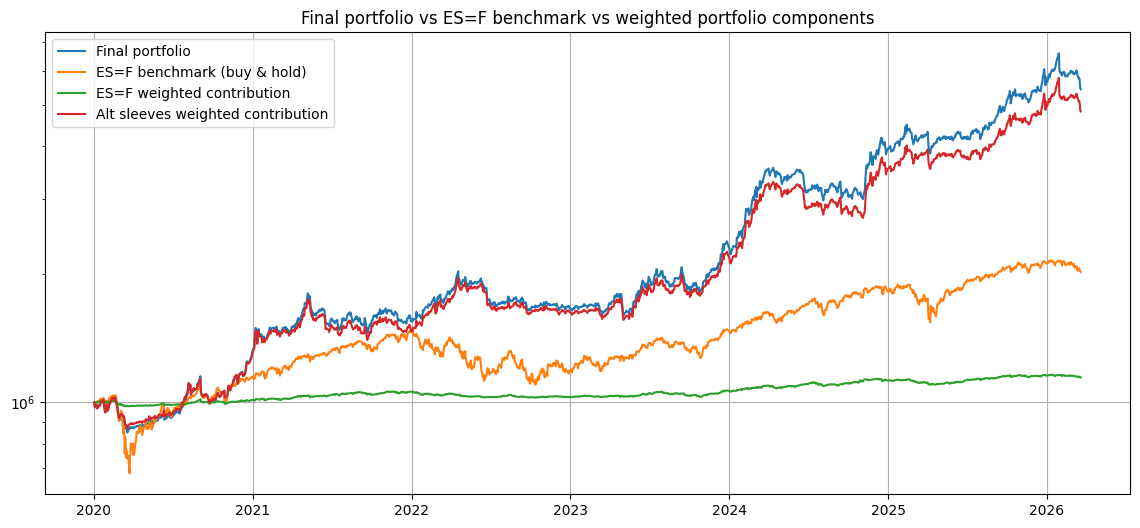

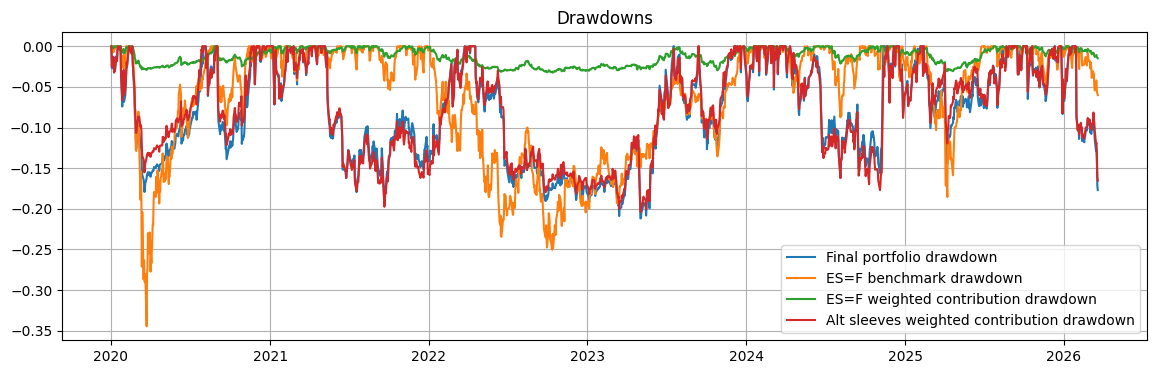

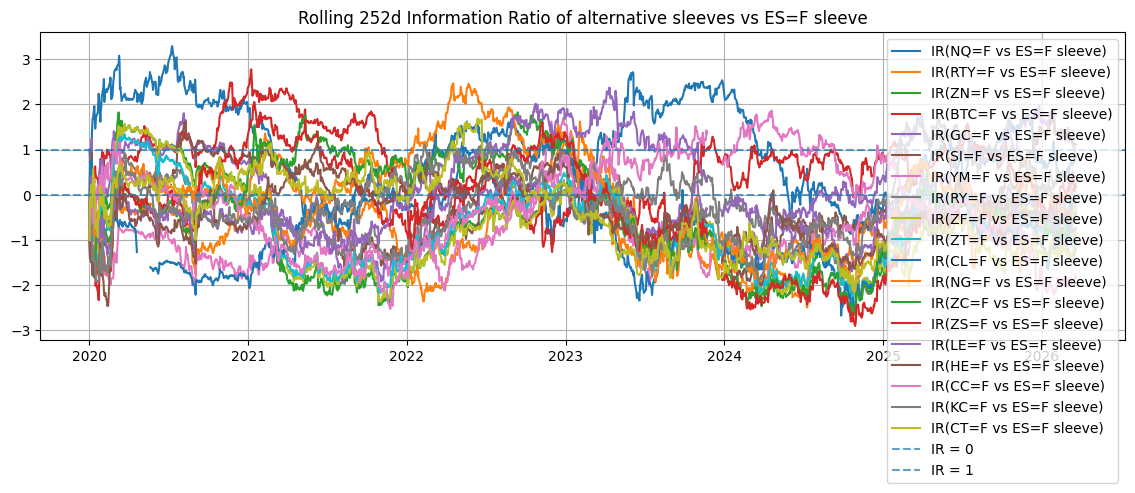

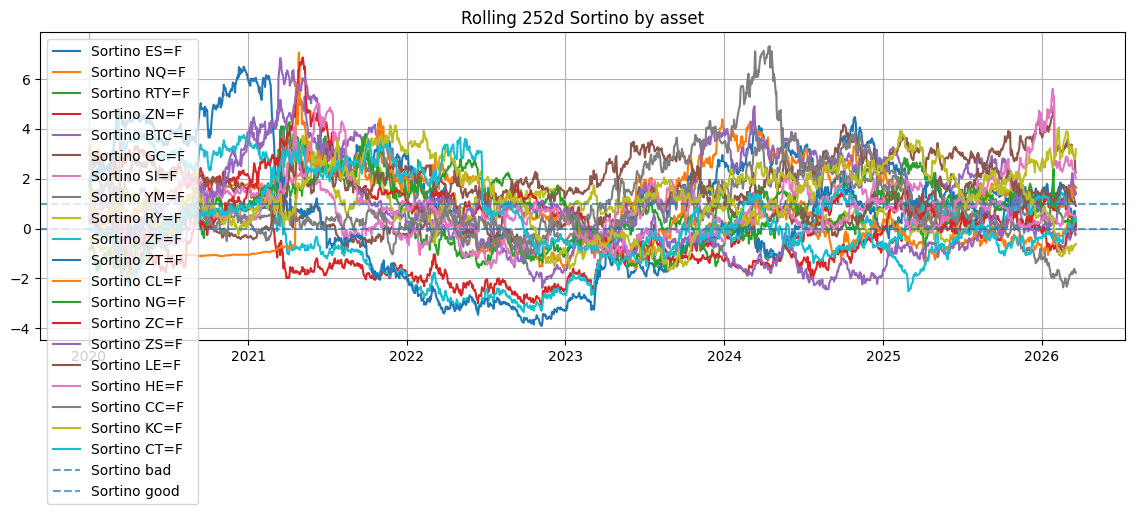

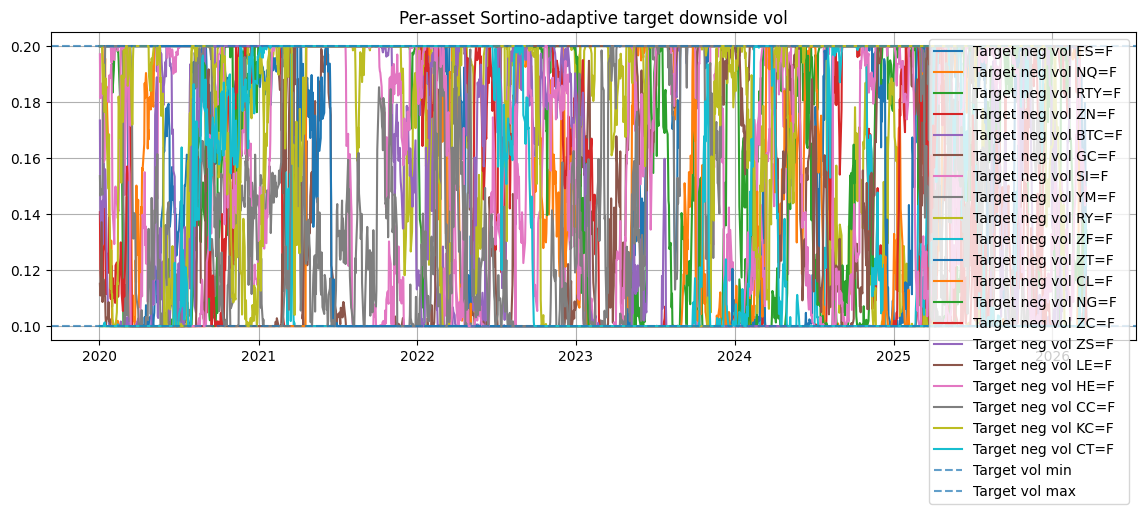

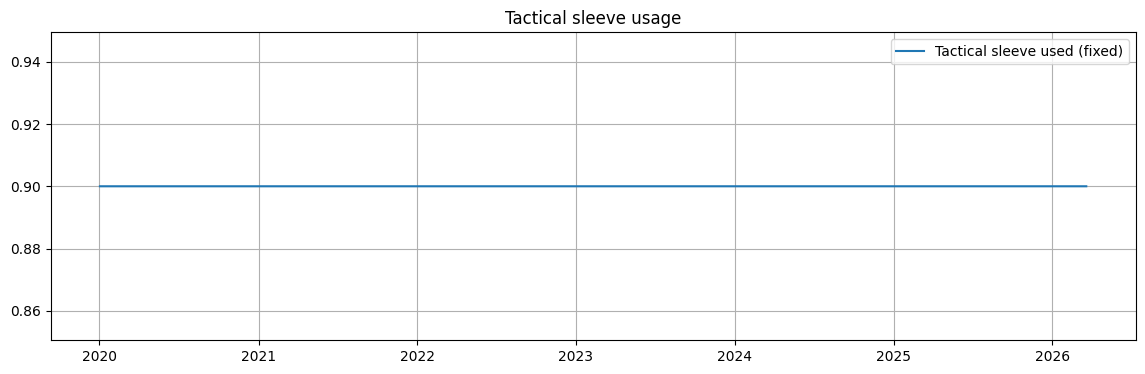

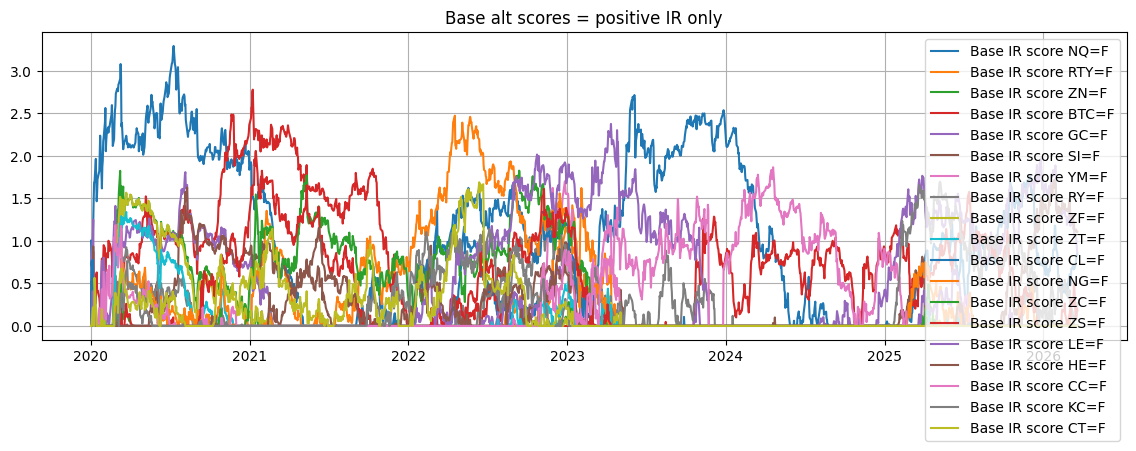

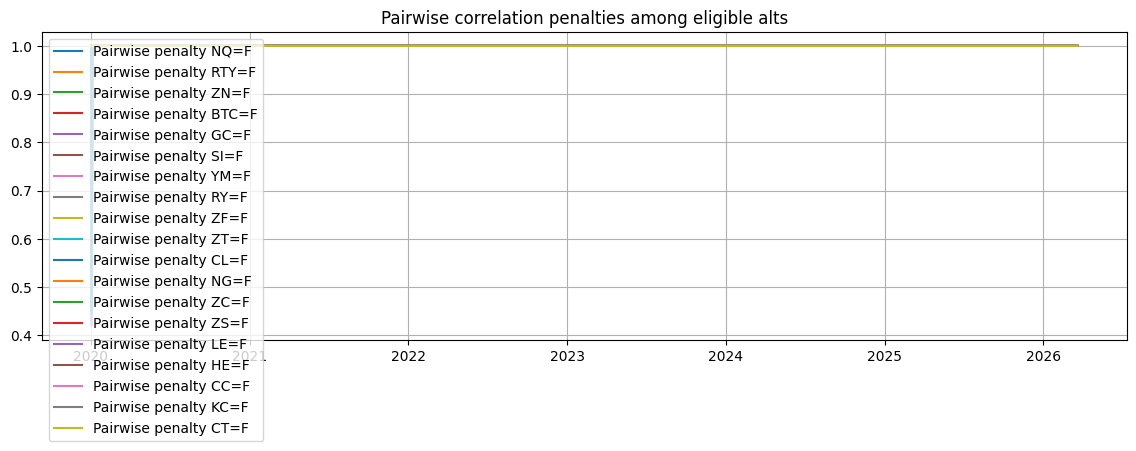

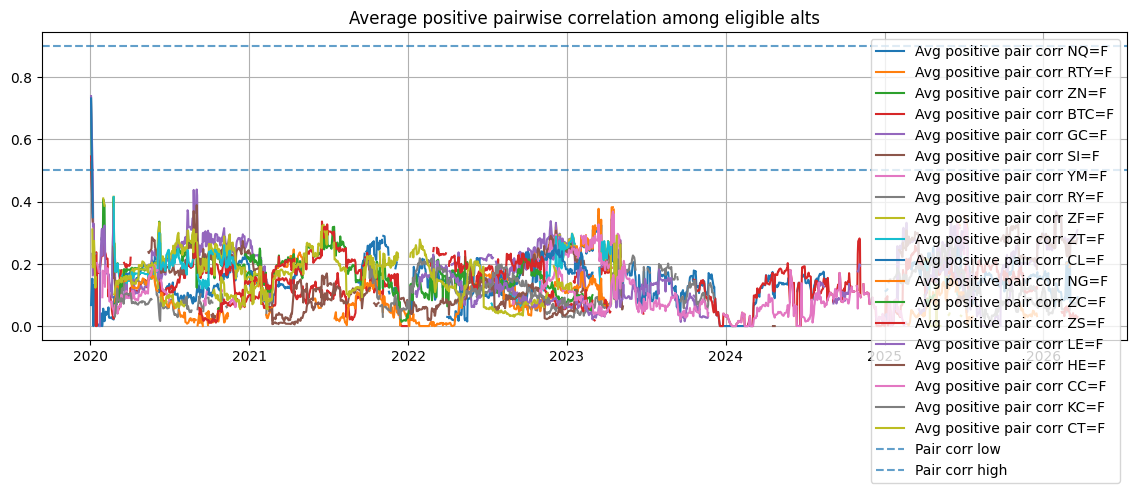

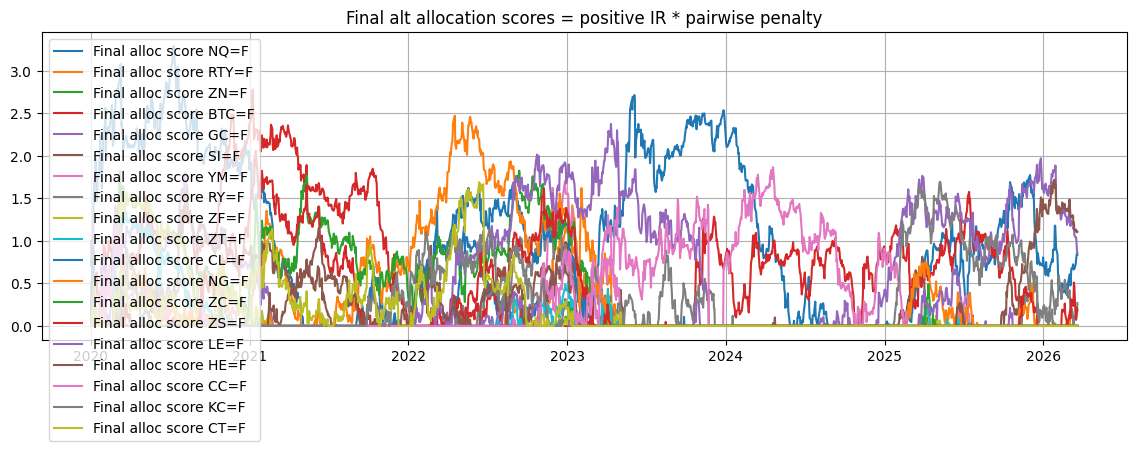

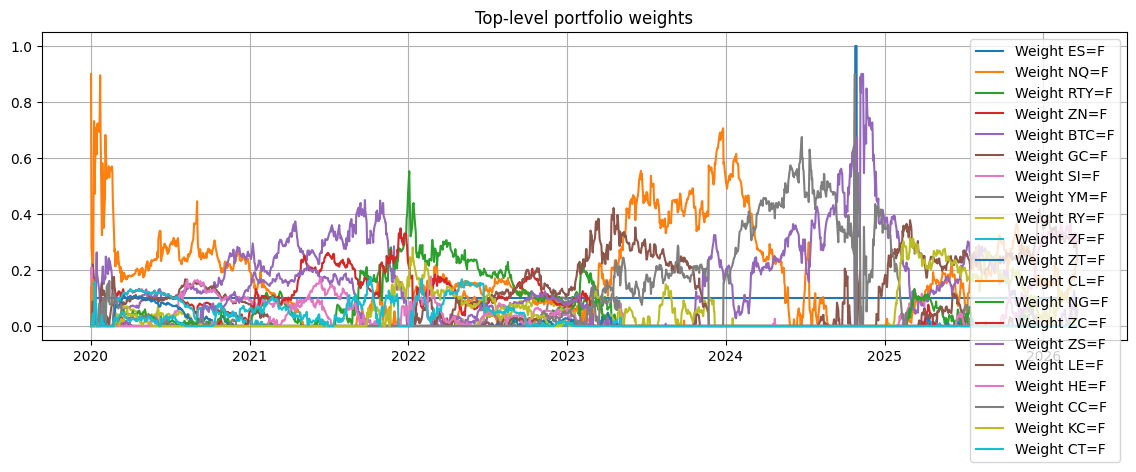

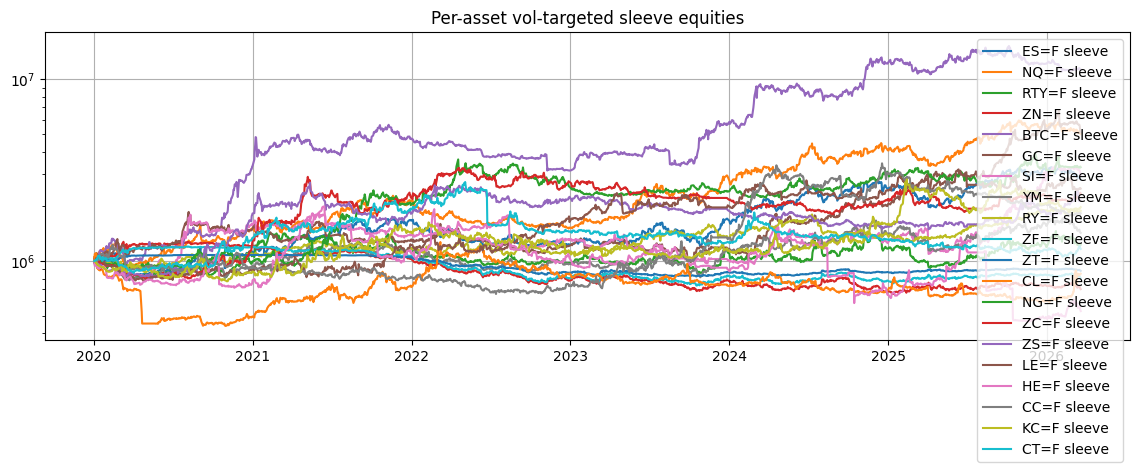

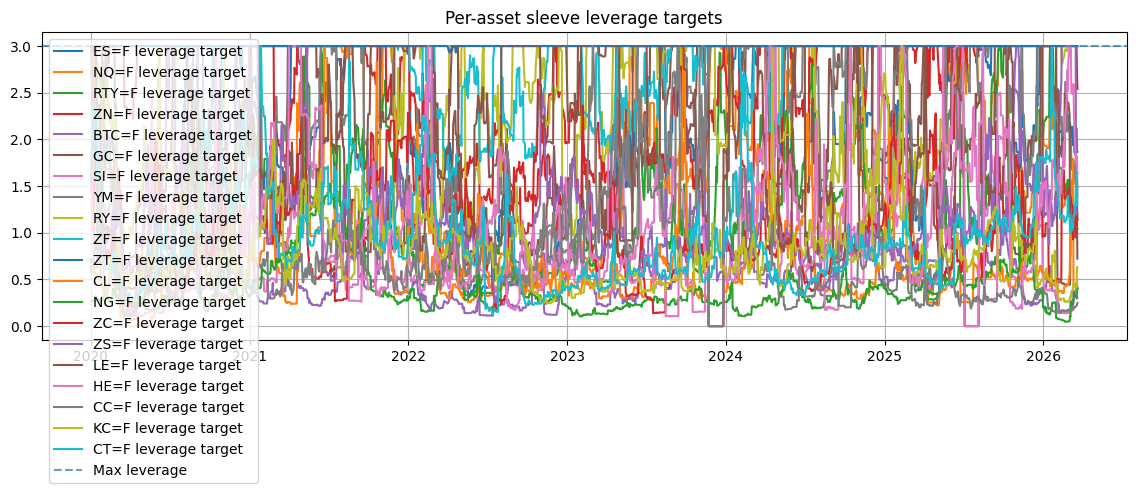

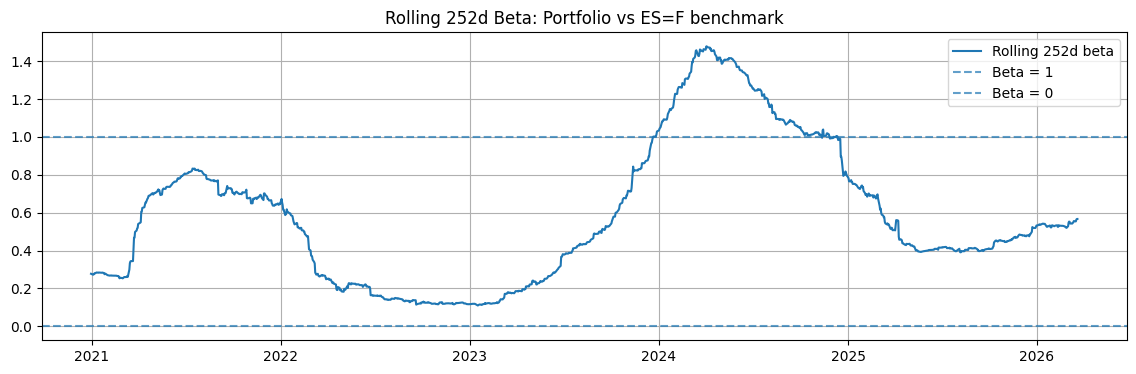

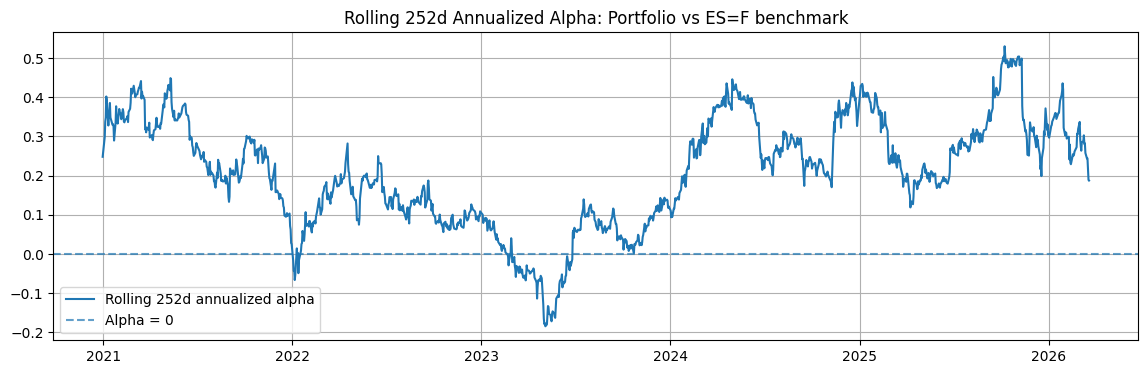

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import vectorbt as vbt

# =========================================================
# Equity Core + Tactical Sleeve Allocator
#
# VERSION:
#   - Sortino used ONLY for per-asset dynamic target downside vol
#   - Information Ratio used ONLY for top-level alt allocation
#   - Tactical sleeve ALWAYS set to TACTICAL_MAX_WEIGHT
#   - Pairwise correlation penalty among eligible alts
#   - If no alt has positive IR, tactical sleeve falls back to equity
#   - Equity graph includes correctly weighted ES and alt contribution lines
#   - Includes rolling 252d beta and annualized alpha vs benchmark
#
# Core idea:
#   1) Build a vol-targeted sleeve for each asset independently
#   2) Use EQUITY_SYMBOL as the core benchmark sleeve
#   3) Compute rolling IR of each alt sleeve vs equity sleeve
#   4) Always reserve TACTICAL_MAX_WEIGHT for the alt bucket
#   5) Base alt allocation on positive IR only
#   6) Penalize alts that are highly correlated with other eligible alts
#   7) Normalize final scores into tactical weights
# =========================================================

# ================== Data source switch ==================
USE_YF = True  # set False to load from MT5 CSV/TSV

# ----- Requested analysis window -----
start = "2020-01-01"
end   = "2026-03-23"

# ----- Symbols -----
EQUITY_SYMBOL = "ES=F"
ALT_SYMBOLS = [
    "NQ=F", "RTY=F", "ZN=F", "BTC=F", "GC=F", "SI=F",
    "YM=F", "RY=F", "ZF=F", "ZT=F", "CL=F", "NG=F",
    "ZC=F", "ZS=F", "LE=F", "HE=F", "CC=F", "KC=F", "CT=F"
]

# Optional per-asset activation dates
ASSET_START_DATES = {
    "ES=F": "2000-01-01",
    "NQ=F": "2000-01-01",
    "RTY=F": "2000-01-01",
    "ZN=F": "2000-01-01",
    "BTC=F": "2017-12-18",
    "GC=F": "2000-01-01",
    "SI=F": "2000-01-01",
}

# ================== Sleeve-level vol targeting inputs ==================
TARGET_NEG_VOL_MIN = 0.10
TARGET_NEG_VOL_MAX = 0.20

FINAL_TARGET_VOL_FLOOR = 0.00
FINAL_TARGET_VOL_CAP   = 0.20

VOL_WINDOW = 21
SORTINO_WINDOW = 252

# Rolling Sortino normalization:
#   Sortino <= SORTINO_BAD  -> normalized score = 0
#   Sortino >= SORTINO_GOOD -> normalized score = 1
SORTINO_BAD  = 0.0
SORTINO_GOOD = 1.0

RealizedVolFloor = 0.01
MAR = 0.0

MaxLeverage = 3.0
MinLeverage = 0.0
FlatEps     = 0.0

# ================== Allocator inputs ==================
IR_WINDOW = 252
TACTICAL_MAX_WEIGHT = 0.90

# Optional smoothing of top-level weights
SMOOTH_ALLOCATIONS   = False
ALLOC_SMOOTH_METHOD  = "ema"
ALLOC_SMOOTH_SPAN    = 5
ALLOC_SMOOTH_WINDOW  = 5

# ================== Pairwise correlation penalty ==================
PAIRWISE_CORR_WINDOW = 63

# avg positive pairwise corr <= LOW  -> no penalty
# avg positive pairwise corr >= HIGH -> max penalty
PAIRWISE_CORR_LOW  = 0.50
PAIRWISE_CORR_HIGH = 0.90

# Maximum penalty at very high correlation
PAIRWISE_PENALTY_STRENGTH = 0.90

# ================== Rolling alpha/beta ==================
ROLLING_AB_WINDOW = 252
TRADING_DAYS = 252
MAR_EQ_RET = 0.0

init_cash = 1_000_000.0

# =========================================================
# Helpers
# =========================================================
def make_index_tz_naive(df: pd.DataFrame) -> pd.DataFrame:
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
    if getattr(df.index, "tz", None) is not None:
        df.index = df.index.tz_convert(None)
    return df

def drawdown_from_equity(eq: pd.Series) -> pd.Series:
    peak = eq.cummax()
    return eq / peak - 1.0

def neg_annualized_vol_from_returns(rets: pd.Series, mar: float = 0.0, freq: int = 252) -> float:
    rets = rets.dropna()
    if len(rets) == 0:
        return float("nan")
    d = np.minimum(rets.to_numpy(dtype=float) - float(mar), 0.0)
    return float(np.sqrt(np.mean(d * d)) * np.sqrt(freq))

def perf_stats_from_equity(eq: pd.Series, freq: int = 252, mar_eq_ret: float = 0.0) -> dict:
    eq = eq.dropna()
    if len(eq) < 2:
        return {
            "total_return": np.nan,
            "cagr": np.nan,
            "ann_vol": np.nan,
            "neg_ann_vol": np.nan,
            "sharpe": np.nan,
            "sortino": np.nan,
            "max_dd": np.nan
        }

    rets = eq.pct_change().dropna()
    total_return = float(eq.iloc[-1] / eq.iloc[0] - 1.0)
    years = (len(eq) - 1) / freq
    cagr = float((eq.iloc[-1] / eq.iloc[0]) ** (1 / years) - 1.0) if years > 0 else np.nan

    ann_vol = float(rets.std(ddof=0) * np.sqrt(freq)) if len(rets) > 1 else np.nan
    neg_ann_vol = neg_annualized_vol_from_returns(rets, mar=mar_eq_ret, freq=freq)

    ann_ret = float(rets.mean() * freq) if len(rets) > 0 else np.nan
    sharpe = float(ann_ret / ann_vol) if ann_vol and ann_vol != 0 else np.nan
    sortino = float(ann_ret / neg_ann_vol) if neg_ann_vol and neg_ann_vol != 0 else np.nan

    max_dd = float(drawdown_from_equity(eq).min())

    return {
        "total_return": total_return,
        "cagr": cagr,
        "ann_vol": ann_vol,
        "neg_ann_vol": neg_ann_vol,
        "sharpe": np.nan if ann_vol == 0 or pd.isna(ann_vol) else sharpe,
        "sortino": np.nan if neg_ann_vol == 0 or pd.isna(neg_ann_vol) else sortino,
        "max_dd": max_dd
    }

def downside_realized_vol(close_s: pd.Series, window: int, mar: float = 0.0,
                          floor: float = 0.0, ann_factor: float = 252.0) -> pd.Series:
    r = np.log(close_s / close_s.shift(1))
    d = np.minimum(r - mar, 0.0)
    rv_down = d.rolling(window, min_periods=window).apply(
        lambda x: np.sqrt(np.mean(np.square(x))), raw=True
    ) * np.sqrt(ann_factor)
    if floor is not None and floor > 0:
        rv_down = rv_down.clip(lower=floor)
    return rv_down

def rolling_sortino_from_returns(rets: pd.Series, window: int = 252, mar: float = 0.0,
                                 ann_factor: int = 252) -> pd.Series:
    rets = rets.astype(float)
    mu_ann = rets.rolling(window, min_periods=window).mean() * ann_factor

    downside = np.minimum(rets - mar, 0.0)
    down_vol_ann = downside.rolling(window, min_periods=window).apply(
        lambda x: np.sqrt(np.mean(np.square(x))), raw=True
    ) * np.sqrt(ann_factor)

    sortino = mu_ann / down_vol_ann.replace(0.0, np.nan)
    return sortino

def smoothstep01(x: pd.Series) -> pd.Series:
    return 3.0 * x**2 - 2.0 * x**3

def map_series_to_unit_interval(s: pd.Series, bad: float, good: float) -> pd.Series:
    x = ((s - bad) / (good - bad)).clip(0.0, 1.0)
    return smoothstep01(x)

def map_sortino_to_target_vol(sortino_s: pd.Series, vol_low: float, vol_high: float,
                              bad: float, good: float) -> pd.Series:
    s_norm = map_series_to_unit_interval(sortino_s, bad=bad, good=good)
    return vol_low + (vol_high - vol_low) * s_norm

def smooth_series(s: pd.Series, method: str = "ema", span: int = 10, window: int = 10) -> pd.Series:
    if method.lower() == "ema":
        return s.ewm(span=span, adjust=False, min_periods=1).mean()
    if method.lower() == "sma":
        return s.rolling(window=window, min_periods=1).mean()
    raise ValueError(f"Unknown smoothing method: {method}")

def rolling_information_ratio(active_ret: pd.Series, window: int = 252) -> pd.Series:
    mu = active_ret.rolling(window, min_periods=window).mean()
    sd = active_ret.rolling(window, min_periods=window).std(ddof=0)
    ir = mu / sd.replace(0.0, np.nan)
    return ir * np.sqrt(TRADING_DAYS)

def rolling_alpha_beta(strat_ret: pd.Series, bench_ret: pd.Series, window: int = 252, ann_factor: int = 252):
    """
    Computes rolling CAPM-like alpha and beta from daily returns:
        beta_t      = Cov(S, B) / Var(B)
        alpha_t     = E[S] - beta_t * E[B]
        alpha_ann_t = alpha_t * ann_factor
    """
    df_ab = pd.concat([strat_ret.rename("S"), bench_ret.rename("B")], axis=1).dropna()
    if df_ab.empty:
        return (
            pd.Series(dtype=float),
            pd.Series(dtype=float)
        )

    S = df_ab["S"]
    B = df_ab["B"]

    meanS = S.rolling(window, min_periods=window).mean()
    meanB = B.rolling(window, min_periods=window).mean()
    covSB = S.rolling(window, min_periods=window).cov(B)
    varB  = B.rolling(window, min_periods=window).var()

    beta = covSB / varB.replace(0.0, np.nan)
    alpha_ann = (meanS - beta * meanB) * ann_factor

    return (
        beta.reindex(strat_ret.index),
        alpha_ann.reindex(strat_ret.index)
    )

def corr_penalty_from_avg_corr(avg_corr: float,
                               corr_low: float,
                               corr_high: float,
                               penalty_strength: float) -> float:
    """
    avg_corr <= corr_low   -> penalty = 1.0
    avg_corr >= corr_high  -> penalty = 1.0 - penalty_strength
    in between             -> smooth transition
    """
    if pd.isna(avg_corr):
        return 1.0
    if avg_corr <= corr_low:
        return 1.0
    if avg_corr >= corr_high:
        return 1.0 - penalty_strength

    x = (avg_corr - corr_low) / (corr_high - corr_low)
    x = float(np.clip(x, 0.0, 1.0))
    s = 3.0 * x**2 - 2.0 * x**3
    return 1.0 - penalty_strength * s

# =========================================================
# Data loading
# =========================================================
all_symbols = [EQUITY_SYMBOL] + ALT_SYMBOLS

requested_start_ts = pd.to_datetime(start)
requested_end_ts   = pd.to_datetime(end)

max_warmup = max(VOL_WINDOW, SORTINO_WINDOW, IR_WINDOW, ROLLING_AB_WINDOW, PAIRWISE_CORR_WINDOW)
if SMOOTH_ALLOCATIONS:
    max_warmup += max(ALLOC_SMOOTH_SPAN, ALLOC_SMOOTH_WINDOW)

warmup_buffer_days = max_warmup + 10
warmup_start_ts = requested_start_ts - pd.offsets.BDay(warmup_buffer_days)

if not USE_YF:
    raise ValueError("USE_YF=False multi-asset mode is not implemented in this script.")

price_dict = {}
for sym in all_symbols:
    data = vbt.YFData.download(sym, start=warmup_start_ts.strftime("%Y-%m-%d"), end=end)
    df_sym = data.get()
    df_sym = df_sym.rename(columns={c: c.capitalize() for c in df_sym.columns})
    if "Close" not in df_sym.columns:
        raise ValueError(f"YF data missing Close for {sym}. Columns: {df_sym.columns.tolist()}")

    df_sym = df_sym[["Close"]].copy()
    df_sym.index = pd.to_datetime(df_sym.index)
    df_sym = make_index_tz_naive(df_sym)
    df_sym.index = df_sym.index.normalize()
    price_dict[sym] = df_sym["Close"].astype(float)

close_df = pd.concat(price_dict, axis=1).sort_index()
close_df = close_df.loc[warmup_start_ts:requested_end_ts].copy()

# Force weekday-only master calendar
close_df = close_df.loc[close_df.index.dayofweek < 5].copy()

dates = close_df.index

if len(close_df) < max_warmup + 3:
    raise ValueError(
        f"Not enough total rows after warmup. Need at least {max_warmup + 3} rows, got {len(close_df)}."
    )

# =========================================================
# Per-asset sleeve construction
# =========================================================
asset_sleeve_equity = {}
asset_sleeve_returns = {}
asset_rv1 = {}
asset_target_vol = {}
asset_sortino = {}
asset_sortino_norm = {}
asset_L_star = {}
asset_L_star_raw = {}
asset_live_mask = {}

for sym in all_symbols:
    close_s = close_df[sym].astype(float)
    start_dt = pd.to_datetime(ASSET_START_DATES.get(sym, start))

    rv_down = downside_realized_vol(
        close_s=close_s,
        window=VOL_WINDOW,
        mar=MAR,
        floor=RealizedVolFloor,
        ann_factor=TRADING_DAYS
    )
    rv1 = rv_down.shift(1)
    asset_rv1[sym] = rv1

    asset_ret = close_s.pct_change()

    roll_sortino = rolling_sortino_from_returns(
        rets=asset_ret,
        window=SORTINO_WINDOW,
        mar=MAR,
        ann_factor=TRADING_DAYS
    )
    asset_sortino[sym] = roll_sortino

    sortino_norm = map_series_to_unit_interval(
        roll_sortino,
        bad=SORTINO_BAD,
        good=SORTINO_GOOD
    )
    asset_sortino_norm[sym] = sortino_norm

    target_vol = map_sortino_to_target_vol(
        sortino_s=roll_sortino,
        vol_low=TARGET_NEG_VOL_MIN,
        vol_high=TARGET_NEG_VOL_MAX,
        bad=SORTINO_BAD,
        good=SORTINO_GOOD
    ).clip(
        lower=FINAL_TARGET_VOL_FLOOR,
        upper=FINAL_TARGET_VOL_CAP
    )
    asset_target_vol[sym] = target_vol

    L_star_raw = (target_vol / rv1).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    L_star = L_star_raw.clip(lower=MinLeverage, upper=MaxLeverage)
    if FlatEps > 0:
        L_star = L_star.where(L_star >= FlatEps, 0.0)

    live_mask = (
        (close_s.index >= start_dt)
        & rv1.notna()
        & target_vol.notna()
        & close_s.notna()
    )
    asset_live_mask[sym] = live_mask

    L_star = L_star.where(live_mask, 0.0)
    L_star_raw = L_star_raw.where(live_mask, 0.0)

    asset_L_star_raw[sym] = L_star_raw
    asset_L_star[sym] = L_star

    asset_ret = asset_ret.fillna(0.0)
    sleeve_ret = (L_star.shift(1).fillna(0.0) * asset_ret).fillna(0.0)
    sleeve_eq = init_cash * (1.0 + sleeve_ret).cumprod()

    asset_sleeve_returns[sym] = sleeve_ret
    asset_sleeve_equity[sym] = sleeve_eq

asset_sleeve_returns_df = pd.DataFrame(asset_sleeve_returns).reindex(dates).fillna(0.0)
asset_sleeve_equity_df = pd.DataFrame(asset_sleeve_equity).reindex(dates).ffill()
asset_sortino_df = pd.DataFrame(asset_sortino).reindex(dates)
asset_sortino_norm_df = pd.DataFrame(asset_sortino_norm).reindex(dates)
asset_target_vol_df = pd.DataFrame(asset_target_vol).reindex(dates)

# Raw benchmark buy-and-hold
benchmark_raw_close = close_df[EQUITY_SYMBOL].astype(float).ffill()
benchmark_raw_ret = benchmark_raw_close.pct_change().fillna(0.0)
benchmark_equity = init_cash * (1.0 + benchmark_raw_ret).cumprod()

# =========================================================
# Rolling IR of each alternative sleeve vs equity sleeve
# =========================================================
equity_sleeve_ret = asset_sleeve_returns_df[EQUITY_SYMBOL].copy()

ir_by_alt = {}
for alt in ALT_SYMBOLS:
    active_ret = asset_sleeve_returns_df[alt] - equity_sleeve_ret
    ir = rolling_information_ratio(active_ret, window=IR_WINDOW)
    ir = ir.where(asset_live_mask[alt], np.nan)
    ir_by_alt[alt] = ir

ir_df = pd.DataFrame(ir_by_alt).reindex(dates)

# =========================================================
# Rolling pairwise correlations among ALT sleeve returns
# =========================================================
alt_returns_df = asset_sleeve_returns_df[ALT_SYMBOLS].copy()

pair_corr = {}
for i in ALT_SYMBOLS:
    for j in ALT_SYMBOLS:
        if i == j:
            continue
        pair_corr[(i, j)] = alt_returns_df[i].rolling(
            PAIRWISE_CORR_WINDOW,
            min_periods=PAIRWISE_CORR_WINDOW
        ).corr(alt_returns_df[j])

# =========================================================
# Tactical sleeve usage and top-level weights
# =========================================================
positive_ir_df = ir_df.clip(lower=0.0)

tactical_usage = pd.Series(1.0, index=dates, dtype=float)
tactical_weight_used = pd.Series(TACTICAL_MAX_WEIGHT, index=dates, dtype=float)

base_score_df = positive_ir_df.copy()

# Force non-live assets to zero base score
for alt in ALT_SYMBOLS:
    base_score_df.loc[~asset_live_mask[alt], alt] = 0.0

# Pairwise diversification penalty
pairwise_avg_corr_df = pd.DataFrame(np.nan, index=dates, columns=ALT_SYMBOLS)
pairwise_penalty_df = pd.DataFrame(1.0, index=dates, columns=ALT_SYMBOLS)

for dt in dates:
    eligible = [alt for alt in ALT_SYMBOLS if base_score_df.loc[dt, alt] > 0.0]

    if len(eligible) <= 1:
        for alt in eligible:
            pairwise_avg_corr_df.loc[dt, alt] = np.nan
            pairwise_penalty_df.loc[dt, alt] = 1.0
        continue

    for alt in eligible:
        others = [o for o in eligible if o != alt]
        corr_vals = []

        for other in others:
            c = pair_corr[(alt, other)].loc[dt]
            if pd.notna(c):
                corr_vals.append(max(float(c), 0.0))

        avg_pos_corr = np.nan if len(corr_vals) == 0 else float(np.mean(corr_vals))
        pairwise_avg_corr_df.loc[dt, alt] = avg_pos_corr
        pairwise_penalty_df.loc[dt, alt] = corr_penalty_from_avg_corr(
            avg_corr=avg_pos_corr,
            corr_low=PAIRWISE_CORR_LOW,
            corr_high=PAIRWISE_CORR_HIGH,
            penalty_strength=PAIRWISE_PENALTY_STRENGTH
        )

alloc_score_df = base_score_df * pairwise_penalty_df

for alt in ALT_SYMBOLS:
    alloc_score_df.loc[~asset_live_mask[alt], alt] = 0.0
    pairwise_penalty_df.loc[~asset_live_mask[alt], alt] = 1.0
    pairwise_avg_corr_df.loc[~asset_live_mask[alt], alt] = np.nan

score_sum = alloc_score_df.sum(axis=1)

alt_weights = pd.DataFrame(0.0, index=dates, columns=ALT_SYMBOLS)

has_positive_score = score_sum > 0.0
for alt in ALT_SYMBOLS:
    alt_weights.loc[has_positive_score, alt] = (
        tactical_weight_used.loc[has_positive_score]
        * alloc_score_df.loc[has_positive_score, alt]
        / score_sum.loc[has_positive_score]
    )

alt_weights = alt_weights.fillna(0.0)

for alt in ALT_SYMBOLS:
    alt_weights.loc[~asset_live_mask[alt], alt] = 0.0

# Residual goes to equity
equity_weight = 1.0 - alt_weights.sum(axis=1)

weights_df = pd.concat(
    [equity_weight.rename(EQUITY_SYMBOL), alt_weights],
    axis=1
).fillna(0.0)

if SMOOTH_ALLOCATIONS:
    for col in weights_df.columns:
        weights_df[col] = smooth_series(
            weights_df[col],
            method=ALLOC_SMOOTH_METHOD,
            span=ALLOC_SMOOTH_SPAN,
            window=ALLOC_SMOOTH_WINDOW
        )
    weights_sum = weights_df.sum(axis=1).replace(0.0, np.nan)
    weights_df = weights_df.div(weights_sum, axis=0).fillna(0.0)

# =========================================================
# Final portfolio from sleeves
# =========================================================
weights_t1 = weights_df.shift(1).fillna(0.0)
portfolio_ret = (weights_t1 * asset_sleeve_returns_df).sum(axis=1)
portfolio_equity = init_cash * (1.0 + portfolio_ret).cumprod()

# Weighted component returns using actual portfolio weights
es_weighted_ret = (
    weights_df[EQUITY_SYMBOL].shift(1).fillna(0.0)
    * asset_sleeve_returns_df[EQUITY_SYMBOL]
).fillna(0.0)

alts_weighted_ret = (
    weights_df[ALT_SYMBOLS].shift(1).fillna(0.0)
    * asset_sleeve_returns_df[ALT_SYMBOLS]
).sum(axis=1).fillna(0.0)

es_weighted_equity = init_cash * (1.0 + es_weighted_ret).cumprod()
alts_weighted_equity = init_cash * (1.0 + alts_weighted_ret).cumprod()

# Standalone ES sleeve diagnostic
equity_only_equity = asset_sleeve_equity_df[EQUITY_SYMBOL].copy()

# =========================================================
# Analysis window
# =========================================================
analysis_mask = dates >= requested_start_ts

portfolio_equity_analysis = portfolio_equity.loc[analysis_mask].dropna()
equity_only_analysis = equity_only_equity.loc[analysis_mask].dropna()
benchmark_analysis = benchmark_equity.loc[analysis_mask].dropna()
es_weighted_analysis = es_weighted_equity.loc[analysis_mask].dropna()
alts_weighted_analysis = alts_weighted_equity.loc[analysis_mask].dropna()

common_idx = portfolio_equity_analysis.index
common_idx = common_idx.intersection(equity_only_analysis.index)
common_idx = common_idx.intersection(benchmark_analysis.index)
common_idx = common_idx.intersection(es_weighted_analysis.index)
common_idx = common_idx.intersection(alts_weighted_analysis.index)

portfolio_equity_analysis = portfolio_equity_analysis.loc[common_idx]
equity_only_analysis = equity_only_analysis.loc[common_idx]
benchmark_analysis = benchmark_analysis.loc[common_idx]
es_weighted_analysis = es_weighted_analysis.loc[common_idx]
alts_weighted_analysis = alts_weighted_analysis.loc[common_idx]

if len(portfolio_equity_analysis) < 2:
    raise ValueError("No valid analysis data in the requested window.")

# REBASE ALL SERIES TO SAME START POINT
first_plot_date = common_idx[0]
portfolio_plot = init_cash * (portfolio_equity_analysis / portfolio_equity_analysis.loc[first_plot_date])
benchmark_plot = init_cash * (benchmark_analysis / benchmark_analysis.loc[first_plot_date])
sleeve_plot = init_cash * (equity_only_analysis / equity_only_analysis.loc[first_plot_date])
es_weighted_plot = init_cash * (es_weighted_analysis / es_weighted_analysis.loc[first_plot_date])
alts_weighted_plot = init_cash * (alts_weighted_analysis / alts_weighted_analysis.loc[first_plot_date])

weights_analysis = weights_df.loc[common_idx]
ir_analysis = ir_df.loc[common_idx]
sortino_analysis = asset_sortino_df.loc[common_idx]
sortino_norm_analysis = asset_sortino_norm_df.loc[common_idx]
target_vol_analysis = asset_target_vol_df.loc[common_idx]
tactical_weight_used_analysis = tactical_weight_used.loc[common_idx]
base_score_analysis = base_score_df.loc[common_idx]
alloc_score_analysis = alloc_score_df.loc[common_idx]
pairwise_penalty_analysis = pairwise_penalty_df.loc[common_idx]
pairwise_avg_corr_analysis = pairwise_avg_corr_df.loc[common_idx]

best_ir = positive_ir_df.max(axis=1).fillna(0.0)
best_ir_analysis = best_ir.loc[common_idx]

# =========================================================
# Rolling alpha/beta vs rebased benchmark (252d)
# =========================================================
strat_rets = portfolio_plot.pct_change().dropna()
bench_rets = benchmark_plot.pct_change().dropna()
ab_idx = strat_rets.index.intersection(bench_rets.index)

beta, alpha_ann = rolling_alpha_beta(
    strat_ret=strat_rets.loc[ab_idx],
    bench_ret=bench_rets.loc[ab_idx],
    window=ROLLING_AB_WINDOW,
    ann_factor=TRADING_DAYS
)

beta_analysis = beta.loc[common_idx.intersection(beta.index)]
alpha_ann_analysis = alpha_ann.loc[common_idx.intersection(alpha_ann.index)]

# =========================================================
# Output
# =========================================================
print("=== Equity Core + Tactical Sleeve Allocator ===")
print("Mode: Sortino for sleeve target vol, IR for base allocation, pairwise corr penalty among eligible alts")
print("Tactical mode: ALWAYS FULL TACTICAL SLEEVE")
print("Equity graph includes correctly weighted ES and alt contribution lines")
print("Includes rolling 252d beta and annualized alpha vs benchmark")
print(f"Equity core symbol: {EQUITY_SYMBOL}")
print(f"Alternative symbols: {ALT_SYMBOLS}")
print(f"Requested analysis window: {requested_start_ts.date()} -> {requested_end_ts.date()}")
print(f"IR window: {IR_WINDOW}")
print(f"Sortino window: {SORTINO_WINDOW}")
print(f"Rolling alpha/beta window: {ROLLING_AB_WINDOW}")
print(f"Tactical sleeve fixed at: {TACTICAL_MAX_WEIGHT:.2f}")
print(f"Target negative vol range: [{TARGET_NEG_VOL_MIN:.2f}, {TARGET_NEG_VOL_MAX:.2f}]")
print(f"Downside realized vol window: {VOL_WINDOW}")
print(f"Pairwise corr window: {PAIRWISE_CORR_WINDOW}")
print(f"Pairwise corr penalty thresholds: low={PAIRWISE_CORR_LOW:.2f}, high={PAIRWISE_CORR_HIGH:.2f}")
print(f"Pairwise penalty strength: {PAIRWISE_PENALTY_STRENGTH:.2f}")
print(f"Max leverage cap per sleeve: {MaxLeverage}")
print()

print("Asset activation dates:")
for sym in all_symbols:
    print(f"  {sym}: {pd.to_datetime(ASSET_START_DATES.get(sym, start)).date()}")
print()

print("Final portfolio stats (rebased comparison window):")
print(perf_stats_from_equity(portfolio_plot, freq=TRADING_DAYS, mar_eq_ret=MAR_EQ_RET))

print(f"\n{EQUITY_SYMBOL} benchmark buy-and-hold stats (rebased comparison window):")
print(perf_stats_from_equity(benchmark_plot, freq=TRADING_DAYS, mar_eq_ret=MAR_EQ_RET))

print(f"\n{EQUITY_SYMBOL} sleeve-only stats (standalone, rebased comparison window):")
print(perf_stats_from_equity(sleeve_plot, freq=TRADING_DAYS, mar_eq_ret=MAR_EQ_RET))

print(f"\n{EQUITY_SYMBOL} weighted contribution stats (actual portfolio weight, rebased):")
print(perf_stats_from_equity(es_weighted_plot, freq=TRADING_DAYS, mar_eq_ret=MAR_EQ_RET))

print(f"\nAlt sleeves weighted contribution stats (actual portfolio weights, rebased):")
print(perf_stats_from_equity(alts_weighted_plot, freq=TRADING_DAYS, mar_eq_ret=MAR_EQ_RET))

last_beta = beta.dropna().iloc[-1] if beta.dropna().shape[0] else np.nan
last_alpha_ann = alpha_ann.dropna().iloc[-1] if alpha_ann.dropna().shape[0] else np.nan

print(f"\nRolling {ROLLING_AB_WINDOW}d alpha/beta vs {EQUITY_SYMBOL} benchmark (latest available):")
print({
    "beta": float(last_beta) if np.isfinite(last_beta) else np.nan,
    "alpha_ann": float(last_alpha_ann) if np.isfinite(last_alpha_ann) else np.nan
})

print("\nLatest tactical allocator snapshot:")
latest_idx = common_idx[-1]
snapshot = {
    "date": str(latest_idx.date()),
    "best_ir_info_only": float(best_ir_analysis.loc[latest_idx]) if pd.notna(best_ir_analysis.loc[latest_idx]) else np.nan,
    "tactical_weight_used": float(tactical_weight_used_analysis.loc[latest_idx]),
    f"target_vol_{EQUITY_SYMBOL}": float(target_vol_analysis.loc[latest_idx, EQUITY_SYMBOL]) if pd.notna(target_vol_analysis.loc[latest_idx, EQUITY_SYMBOL]) else np.nan,
    f"sortino_{EQUITY_SYMBOL}": float(sortino_analysis.loc[latest_idx, EQUITY_SYMBOL]) if pd.notna(sortino_analysis.loc[latest_idx, EQUITY_SYMBOL]) else np.nan,
    f"weight_{EQUITY_SYMBOL}": float(weights_analysis.loc[latest_idx, EQUITY_SYMBOL]),
    "weight_total_alts": float(weights_analysis.loc[latest_idx, ALT_SYMBOLS].sum()),
    "rolling_beta_portfolio_vs_benchmark": float(beta.loc[latest_idx]) if latest_idx in beta.index and pd.notna(beta.loc[latest_idx]) else np.nan,
    "rolling_alpha_ann_portfolio_vs_benchmark": float(alpha_ann.loc[latest_idx]) if latest_idx in alpha_ann.index and pd.notna(alpha_ann.loc[latest_idx]) else np.nan,
}
for alt in ALT_SYMBOLS:
    snapshot[f"weight_{alt}"] = float(weights_analysis.loc[latest_idx, alt])
    snapshot[f"ir_{alt}"] = float(ir_analysis.loc[latest_idx, alt]) if pd.notna(ir_analysis.loc[latest_idx, alt]) else np.nan
    snapshot[f"sortino_{alt}"] = float(sortino_analysis.loc[latest_idx, alt]) if pd.notna(sortino_analysis.loc[latest_idx, alt]) else np.nan
    snapshot[f"sortino_norm_{alt}"] = float(sortino_norm_analysis.loc[latest_idx, alt]) if pd.notna(sortino_norm_analysis.loc[latest_idx, alt]) else np.nan
    snapshot[f"target_vol_{alt}"] = float(target_vol_analysis.loc[latest_idx, alt]) if pd.notna(target_vol_analysis.loc[latest_idx, alt]) else np.nan
    snapshot[f"base_score_{alt}"] = float(base_score_analysis.loc[latest_idx, alt]) if pd.notna(base_score_analysis.loc[latest_idx, alt]) else np.nan
    snapshot[f"pairwise_avg_corr_{alt}"] = float(pairwise_avg_corr_analysis.loc[latest_idx, alt]) if pd.notna(pairwise_avg_corr_analysis.loc[latest_idx, alt]) else np.nan
    snapshot[f"pairwise_penalty_{alt}"] = float(pairwise_penalty_analysis.loc[latest_idx, alt]) if pd.notna(pairwise_penalty_analysis.loc[latest_idx, alt]) else np.nan
    snapshot[f"alloc_score_{alt}"] = float(alloc_score_analysis.loc[latest_idx, alt]) if pd.notna(alloc_score_analysis.loc[latest_idx, alt]) else np.nan
print(snapshot)

# =========================================================
# Plots
# =========================================================
plt.figure(figsize=(14, 6))
plt.plot(portfolio_plot, label="Final portfolio")
plt.plot(benchmark_plot, label=f"{EQUITY_SYMBOL} benchmark (buy & hold)")
plt.plot(es_weighted_plot, label=f"{EQUITY_SYMBOL} weighted contribution")
plt.plot(alts_weighted_plot, label="Alt sleeves weighted contribution")
plt.yscale("log")
plt.title(f"Final portfolio vs {EQUITY_SYMBOL} benchmark vs weighted portfolio components")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(drawdown_from_equity(portfolio_plot), label="Final portfolio drawdown")
plt.plot(drawdown_from_equity(benchmark_plot), label=f"{EQUITY_SYMBOL} benchmark drawdown")
plt.plot(drawdown_from_equity(es_weighted_plot), label=f"{EQUITY_SYMBOL} weighted contribution drawdown")
plt.plot(drawdown_from_equity(alts_weighted_plot), label="Alt sleeves weighted contribution drawdown")
plt.title("Drawdowns")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
for alt in ALT_SYMBOLS:
    plt.plot(ir_analysis[alt], label=f"IR({alt} vs {EQUITY_SYMBOL} sleeve)")
plt.axhline(0.0, linestyle="--", alpha=0.7, label="IR = 0")
plt.axhline(1.0, linestyle="--", alpha=0.7, label="IR = 1")
plt.title(f"Rolling {IR_WINDOW}d Information Ratio of alternative sleeves vs {EQUITY_SYMBOL} sleeve")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
for sym in all_symbols:
    plt.plot(sortino_analysis[sym], label=f"Sortino {sym}")
plt.axhline(SORTINO_BAD, linestyle="--", alpha=0.7, label="Sortino bad")
plt.axhline(SORTINO_GOOD, linestyle="--", alpha=0.7, label="Sortino good")
plt.title(f"Rolling {SORTINO_WINDOW}d Sortino by asset")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
for sym in all_symbols:
    plt.plot(target_vol_analysis[sym], label=f"Target neg vol {sym}")
plt.axhline(TARGET_NEG_VOL_MIN, linestyle="--", alpha=0.7, label="Target vol min")
plt.axhline(TARGET_NEG_VOL_MAX, linestyle="--", alpha=0.7, label="Target vol max")
plt.title("Per-asset Sortino-adaptive target downside vol")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(tactical_weight_used_analysis, label="Tactical sleeve used (fixed)")
plt.title("Tactical sleeve usage")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
for alt in ALT_SYMBOLS:
    plt.plot(base_score_analysis[alt], label=f"Base IR score {alt}")
plt.title("Base alt scores = positive IR only")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
for alt in ALT_SYMBOLS:
    plt.plot(pairwise_penalty_analysis[alt], label=f"Pairwise penalty {alt}")
plt.title("Pairwise correlation penalties among eligible alts")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
for alt in ALT_SYMBOLS:
    plt.plot(pairwise_avg_corr_analysis[alt], label=f"Avg positive pair corr {alt}")
plt.axhline(PAIRWISE_CORR_LOW, linestyle="--", alpha=0.7, label="Pair corr low")
plt.axhline(PAIRWISE_CORR_HIGH, linestyle="--", alpha=0.7, label="Pair corr high")
plt.title("Average positive pairwise correlation among eligible alts")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
for alt in ALT_SYMBOLS:
    plt.plot(alloc_score_analysis[alt], label=f"Final alloc score {alt}")
plt.title("Final alt allocation scores = positive IR * pairwise penalty")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
for sym in weights_analysis.columns:
    plt.plot(weights_analysis[sym], label=f"Weight {sym}")
plt.title("Top-level portfolio weights")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
for sym in all_symbols:
    plt.plot(asset_sleeve_equity_df.loc[common_idx, sym], label=f"{sym} sleeve")
plt.yscale("log")
plt.title("Per-asset vol-targeted sleeve equities")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
for sym in all_symbols:
    plt.plot(asset_L_star[sym].loc[common_idx], label=f"{sym} leverage target")
plt.axhline(MaxLeverage, linestyle="--", alpha=0.7, label="Max leverage")
plt.title("Per-asset sleeve leverage targets")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(beta_analysis, label=f"Rolling {ROLLING_AB_WINDOW}d beta")
plt.axhline(1.0, linestyle="--", alpha=0.7, label="Beta = 1")
plt.axhline(0.0, linestyle="--", alpha=0.7, label="Beta = 0")
plt.title(f"Rolling {ROLLING_AB_WINDOW}d Beta: Portfolio vs {EQUITY_SYMBOL} benchmark")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(alpha_ann_analysis, label=f"Rolling {ROLLING_AB_WINDOW}d annualized alpha")
plt.axhline(0.0, linestyle="--", alpha=0.7, label="Alpha = 0")
plt.title(f"Rolling {ROLLING_AB_WINDOW}d Annualized Alpha: Portfolio vs {EQUITY_SYMBOL} benchmark")
plt.grid(True)
plt.legend()
plt.show()